#Imports & Configs



In [12]:
from google.colab import drive
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

csv_path = '/content/drive/MyDrive/SIC Project/Modeling/Currency/3300 rows/last tests/eur_dzd_dataset_database.csv'

OUT_DIR = '/content/drive/MyDrive/SIC Project/Modeling/Currency/artifacts'
os.makedirs(OUT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Evolution Plot EUR/DZD

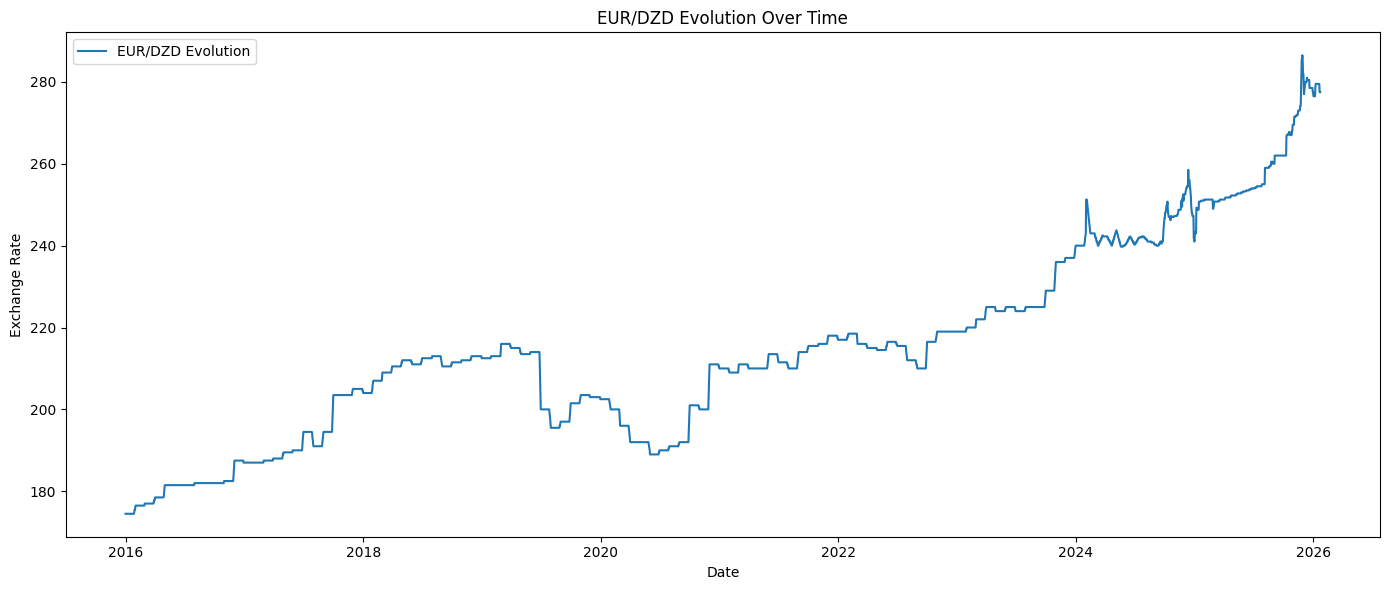

In [13]:
df = pd.read_csv(csv_path)

DATE_COL = "date"
TARGET_COL = "eur_dzd_parallel"

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

df = df.dropna(subset=[DATE_COL, TARGET_COL]).sort_values(DATE_COL)

plt.figure(figsize=(14,6))
plt.plot(df[DATE_COL], df[TARGET_COL], label="EUR/DZD Evolution")
plt.title("EUR/DZD Evolution Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.tight_layout()
plt.show()

#Data Exploratory Analysis

Dataset shape: (3675, 58)

Missing values:
 id                         0
eur_dzd_parallel           0
eur_dzd_official           0
eur_usd                    0
brent_oil                  3
dxy                        3
spread                     0
spread_pct                 0
premium                    0
year                       0
month                      0
quarter                    0
day_of_week                0
day_of_month               0
week_of_year               0
is_month_start             0
is_month_end               0
days_since_start           0
eur_dzd_parallel_ma7       0
eur_dzd_parallel_std7      1
spread_pct_ma7             0
brent_oil_ma7              3
eur_usd_ma7                0
eur_dzd_parallel_ma30      0
eur_dzd_parallel_std30     1
spread_pct_ma30            0
brent_oil_ma30             3
eur_usd_ma30               0
eur_dzd_parallel_ma90      0
eur_dzd_parallel_std90     1
spread_pct_ma90            0
brent_oil_ma90             3
eur_usd_ma90               0

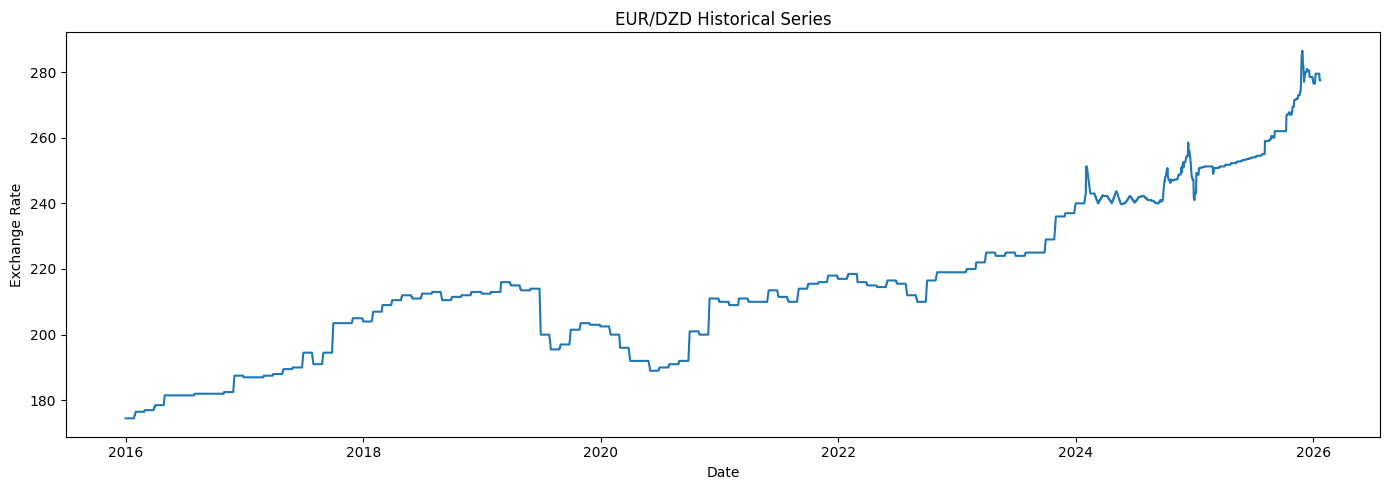

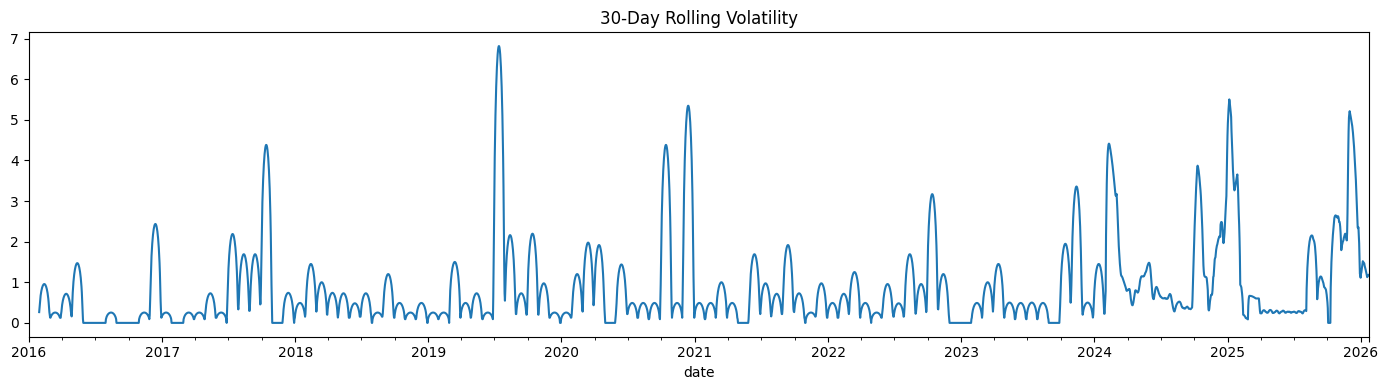

<Figure size 1000x400 with 0 Axes>

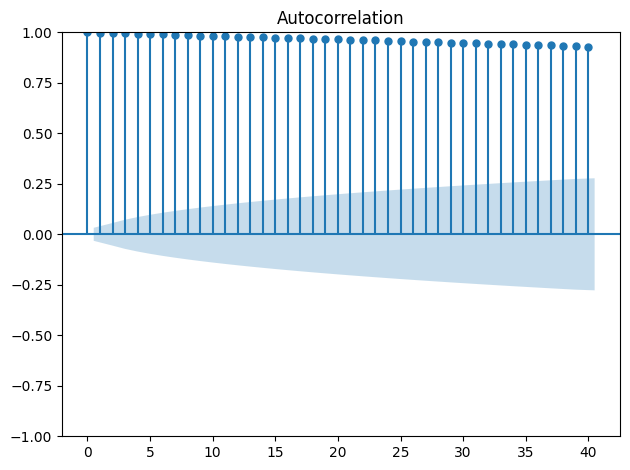

In [14]:
DATE_COL = "date"
TARGET_COL = "eur_dzd_parallel"

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET_COL]).sort_values(DATE_COL).set_index(DATE_COL)

print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())

print("\nDescriptive statistics:\n", df[TARGET_COL].describe())

adf_result = adfuller(df[TARGET_COL])
print("\nADF p-value:", adf_result[1])

plt.figure(figsize=(14,5))
plt.plot(df.index, df[TARGET_COL])
plt.title("EUR/DZD Historical Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,4))
df[TARGET_COL].rolling(30).std().plot()
plt.title("30-Day Rolling Volatility")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plot_acf(df[TARGET_COL], lags=40)
plt.tight_layout()
plt.show()

#Data Cleaning & Feature Engineering

In [2]:
df = pd.read_csv(csv_path)

DATE_COL = "date"
TARGET_COL = "eur_dzd_parallel"

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).set_index(DATE_COL)

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[TARGET_COL])

for lag in [1, 2, 3, 7, 14, 30]:
    df[f"lag{lag}"] = df[TARGET_COL].shift(lag)

for window in [7, 14, 30]:
    df[f"ma{window}"] = df[TARGET_COL].rolling(window).mean()
    df[f"std{window}"] = df[TARGET_COL].rolling(window).std()

df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)
df["dow_sin"]   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df.index.dayofweek / 7)

df_feat = df.dropna().copy()

feature_cols = [c for c in df_feat.columns if c != TARGET_COL]
X = df_feat[feature_cols].values
y = df_feat[TARGET_COL].values

#Model Training and Hyperparameter Optimization

In [5]:
from sklearn.impute import SimpleImputer

split_idx = int(len(df_feat) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

X_train = pd.DataFrame(X_train).apply(pd.to_numeric, errors='coerce').values
X_val = pd.DataFrame(X_val).apply(pd.to_numeric, errors='coerce').values

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {"model__alpha": [0.1, 0.3, 1.0, 3.0, 10.0]}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print("Best params:", grid.best_params_)
print(f"VAL | MAE={mae:.4f} | RMSE={rmse:.4f}")

Best params: {'model__alpha': 0.1}
VAL | MAE=0.0609 | RMSE=0.1320


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [56]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [56]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


#Model Saving, Validation Log, and Error Analysis

In [6]:
import joblib

model_path = os.path.join(OUT_DIR, "ridge_timeseries_best.pkl")
joblib.dump(best_model, model_path)

final_log = f"FINAL_VAL | MAE={mae:.6f} | RMSE={rmse:.6f} | ckpt={os.path.basename(model_path)}"
print(final_log)

err = np.abs(y_val - y_pred)
top_idx = np.argsort(-err)[:5]

analysis = pd.DataFrame({
    "date": df_feat.index[split_idx:][top_idx],
    "y_true": y_val[top_idx],
    "y_pred": y_pred[top_idx],
    "abs_error": err[top_idx],
}).sort_values("abs_error", ascending=False)

analysis

FINAL_VAL | MAE=0.060860 | RMSE=0.132004 | ckpt=ridge_timeseries_best.pkl


,date,y_true,y_pred,abs_error
0,2024-02-02,251.25,249.950517,1.299483
1,2025-01-06,249.25,248.294907,0.955093
2,2024-12-29,241.75,242.644458,0.894458
3,2025-10-10,266.75,266.003119,0.746881
4,2024-12-13,256.00,256.730476,0.730476


#Historical Series and Forecast Visualization

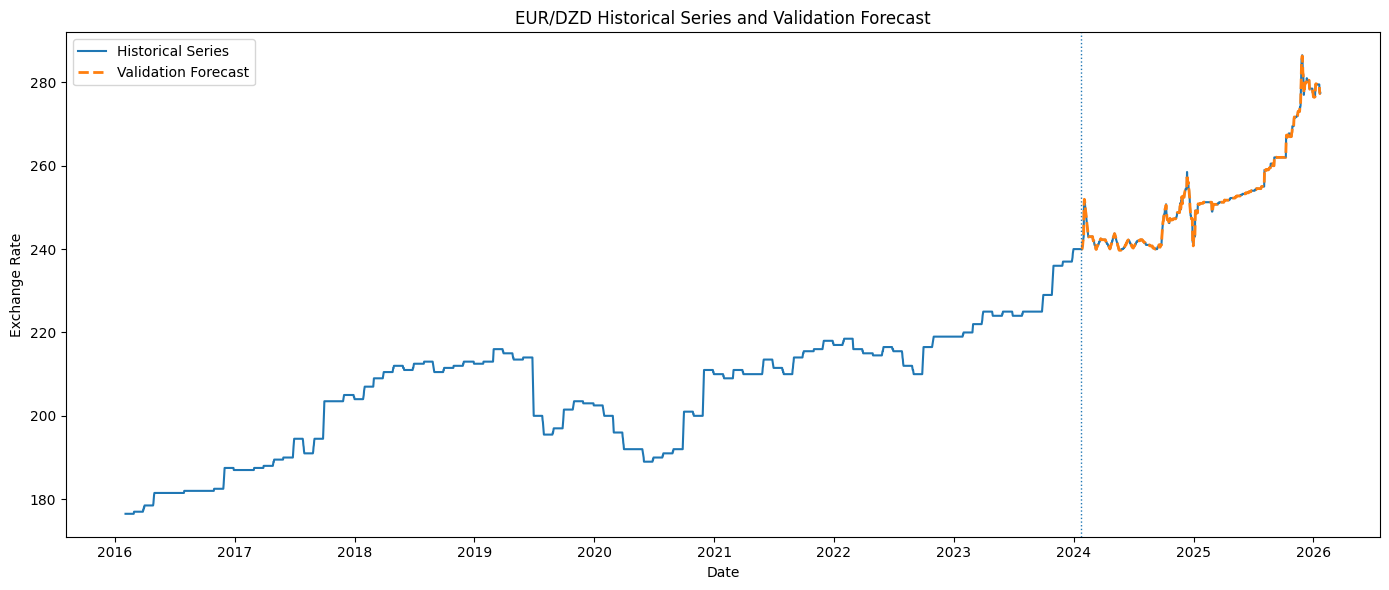

In [8]:
import matplotlib.pyplot as plt

val_dates = df_feat.index[split_idx:]

plt.figure(figsize=(14,6))

plt.plot(df_feat.index, df_feat[TARGET_COL], label="Historical Series")
plt.plot(val_dates, y_pred, linestyle="--", linewidth=2, label="Validation Forecast")

plt.axvline(val_dates[0], linestyle=":", linewidth=1)
plt.title("EUR/DZD Historical Series and Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()

plt.tight_layout()
plt.show()


#Baseline Comparison

In [15]:
naive_pred = y_val[:-1]
naive_true = y_val[1:]

naive_mae = mean_absolute_error(naive_true, naive_pred)
print("Naive MAE:", naive_mae)

Naive MAE: 0.23832417582417584


In [16]:
direction_true = np.sign(np.diff(y_val))
direction_pred = np.sign(np.diff(y_pred))

direction_acc = (direction_true == direction_pred).mean()
print("Directional accuracy:", direction_acc)

Directional accuracy: 0.2925824175824176


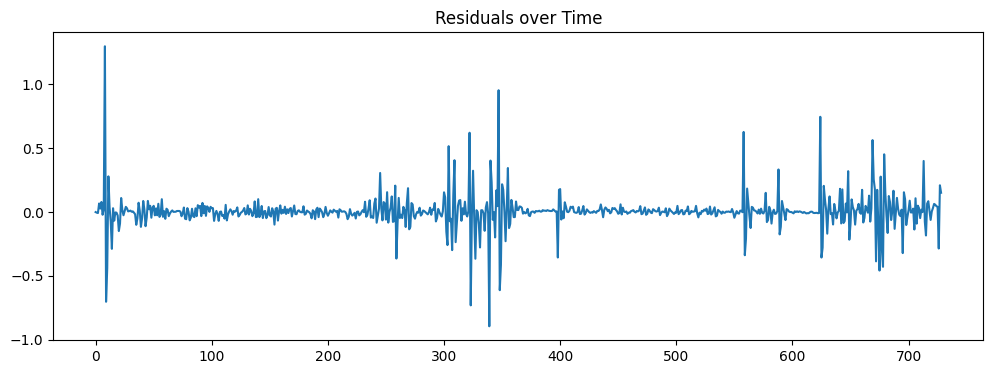

Residual mean: 0.004695698149665068


In [17]:
residuals = y_val - y_pred

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals over Time")
plt.show()

print("Residual mean:", residuals.mean())